<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>

### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Damiel Vargas
- Nombre de alumno 2: Rafael Tapia

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/rodusflitope/DataScienceLabs/tree/lab10)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Miercoles a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

In [3]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

In [4]:
df_energia = pd.read_csv('energia_homero.csv')
df_energia['date'] = pd.to_datetime(df_energia['date'])

fig = px.line(df_energia, x='date', y='Energy_kWh', title='Consumo de Energía de Homero')
fig.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

MAE Train: 10.5682
MAE Test: 8.6558


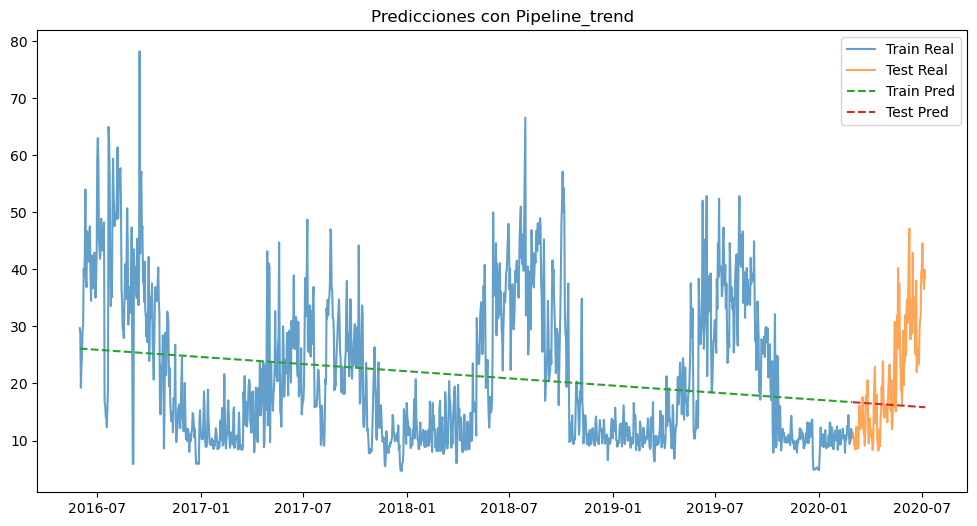

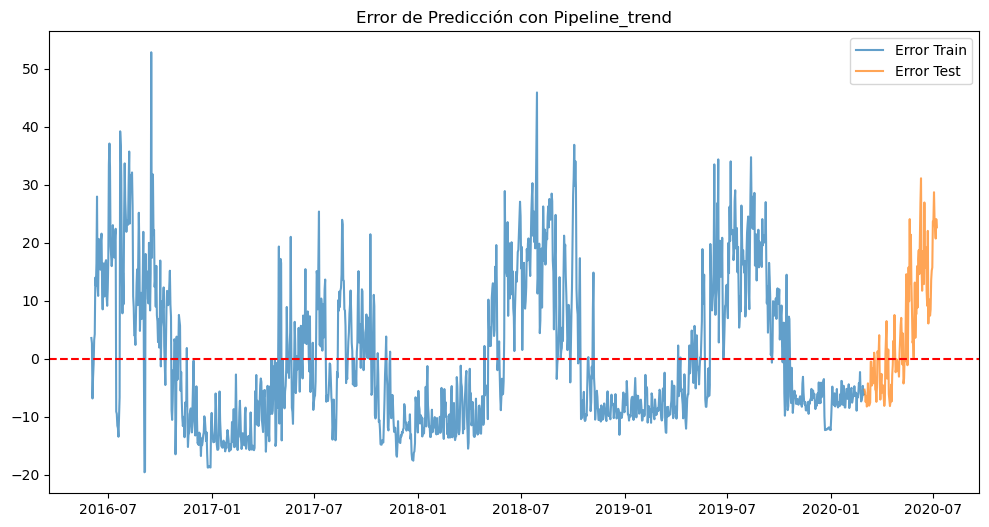


MAE Train (Seasonal): 5.3006
MAE Test (Seasonal): 4.4030


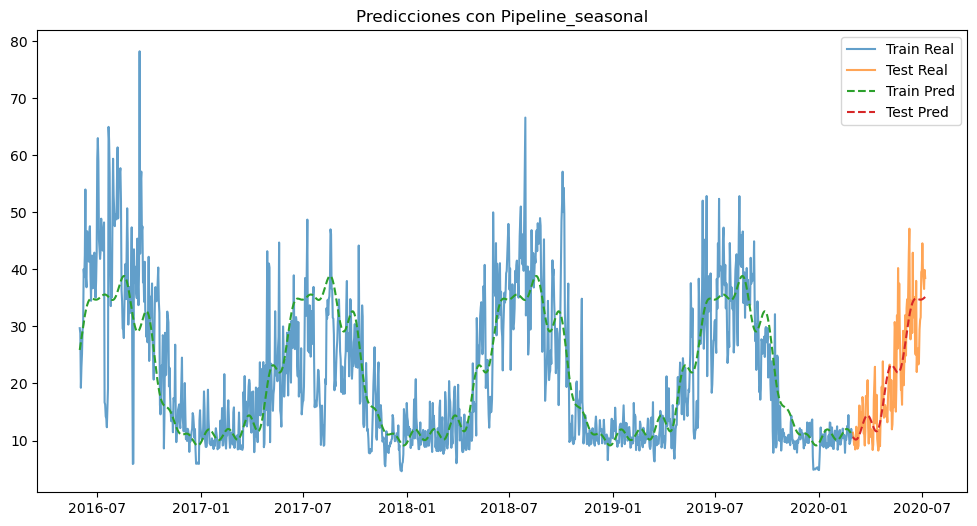

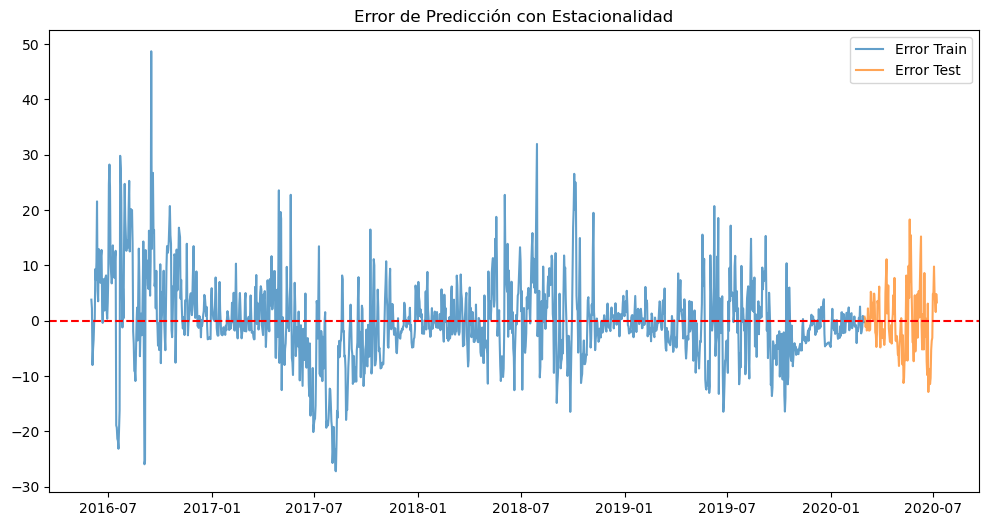

El error se reduce significativamente con el modelo estacional.


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
    
train = df_energia[df_energia['date'] <= '2020-02-29'].copy()
test = df_energia[df_energia['date'] >= '2020-03-01'].copy()
train['day_index'] = (train['date'] - train['date'].min()).dt.days
test['day_index'] = (test['date'] - train['date'].min()).dt.days

Pipeline_trend = Pipeline([
    ('model', LinearRegression())
])

X_train = train[['day_index']]
y_train = train['Energy_kWh']
X_test = test[['day_index']]
y_test = test['Energy_kWh']

Pipeline_trend.fit(X_train, y_train)

y_pred_train = Pipeline_trend.predict(X_train)
y_pred_test = Pipeline_trend.predict(X_test)

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f'MAE Train: {mae_train:.4f}')
print(f'MAE Test: {mae_test:.4f}')

plt.figure(figsize=(12, 6))
plt.plot(train['date'], y_train, label='Train Real', alpha=0.7)
plt.plot(test['date'], y_test, label='Test Real', alpha=0.7)
plt.plot(train['date'], y_pred_train, label='Train Pred', linestyle='--')
plt.plot(test['date'], y_pred_test, label='Test Pred', linestyle='--')
plt.legend()
plt.title('Predicciones con Pipeline_trend')
plt.show()

error_train = y_train - y_pred_train
error_test = y_test - y_pred_test

plt.figure(figsize=(12, 6))
plt.plot(train['date'], error_train, label='Error Train', alpha=0.7)
plt.plot(test['date'], error_test, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error de Predicción con Pipeline_trend')
plt.show()

def fourier_features(X, period, n_terms):
    features = []
    for i in range(1, n_terms + 1):
        features.append(np.sin(2 * np.pi * i * X / period))
        features.append(np.cos(2 * np.pi * i * X / period))
    return np.column_stack(features)

P = 365
n = 10

X_train_fourier = fourier_features(train['day_index'].values, P, n)
X_test_fourier = fourier_features(test['day_index'].values, P, n)

Pipeline_seasonal = Pipeline([
    ('model', LinearRegression())
])

Pipeline_seasonal.fit(X_train_fourier, y_train)

y_pred_train_seasonal = Pipeline_seasonal.predict(X_train_fourier)
y_pred_test_seasonal = Pipeline_seasonal.predict(X_test_fourier)

mae_train_seasonal = mean_absolute_error(y_train, y_pred_train_seasonal)
mae_test_seasonal = mean_absolute_error(y_test, y_pred_test_seasonal)

print(f'\nMAE Train (Seasonal): {mae_train_seasonal:.4f}')
print(f'MAE Test (Seasonal): {mae_test_seasonal:.4f}')

plt.figure(figsize=(12, 6))
plt.plot(train['date'], y_train, label='Train Real', alpha=0.7)
plt.plot(test['date'], y_test, label='Test Real', alpha=0.7)
plt.plot(train['date'], y_pred_train_seasonal, label='Train Pred', linestyle='--')
plt.plot(test['date'], y_pred_test_seasonal, label='Test Pred', linestyle='--')
plt.legend()
plt.title('Predicciones con Pipeline_seasonal')
plt.show()

error_train_seasonal = y_train - y_pred_train_seasonal
error_test_seasonal = y_test - y_pred_test_seasonal

plt.figure(figsize=(12, 6))
plt.plot(train['date'], error_train_seasonal, label='Error Train', alpha=0.7)
plt.plot(test['date'], error_test_seasonal, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error de Predicción con Estacionalidad')
plt.show()

print("El error se reduce significativamente con el modelo estacional.")

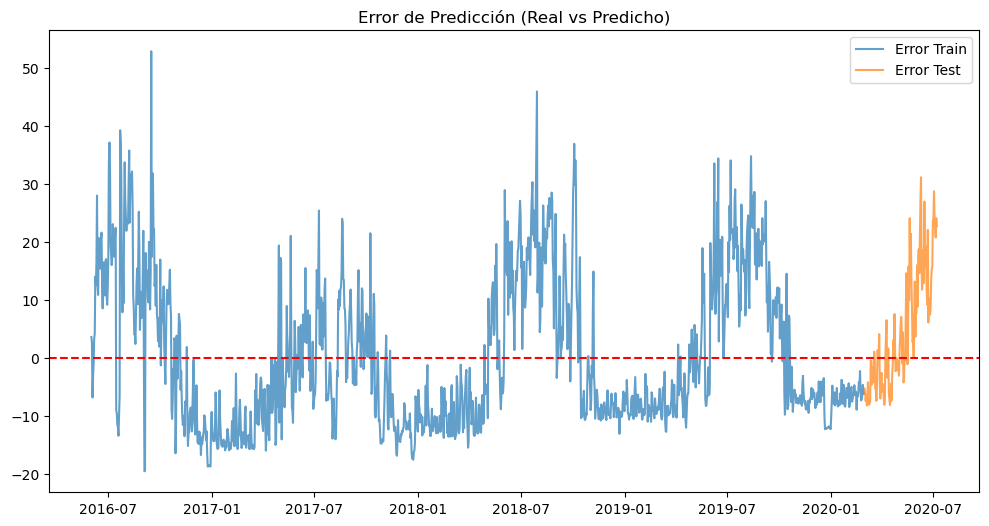

In [6]:
#Punto 3
error_train = y_train - y_pred_train
error_test = y_test - y_pred_test

plt.figure(figsize=(12, 6))
plt.plot(train['date'], error_train, label='Error Train', alpha=0.7)
plt.plot(test['date'], error_test, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error de Predicción (Real vs Predicho)')
plt.show()

Se nota claramente un comportamiento estacional pues podemos ver un patron ciclico que depende del tiempo del año para cada año


MAE Train (Seasonal): 5.3006
MAE Test (Seasonal): 4.4030


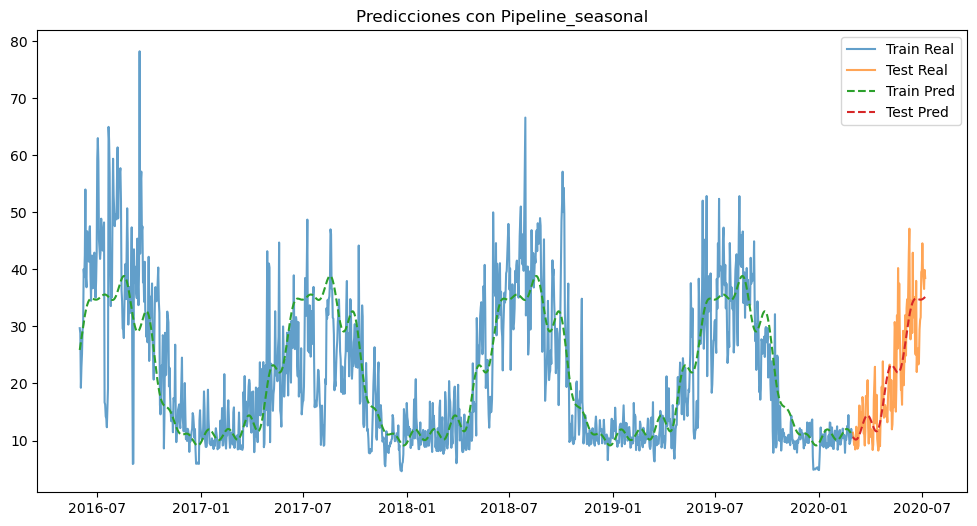

In [7]:
#Punto 4 y 5
def fourier_features(X, period, n_terms):
    features = []
    for i in range(1, n_terms + 1):
        features.append(np.sin(2 * np.pi * i * X / period))
        features.append(np.cos(2 * np.pi * i * X / period))
    return np.column_stack(features)

P = 365
n = 10

X_train_fourier = fourier_features(train['day_index'].values, P, n)
X_test_fourier = fourier_features(test['day_index'].values, P, n)

Pipeline_seasonal = Pipeline([
    ('model', LinearRegression())
])

Pipeline_seasonal.fit(X_train_fourier, y_train)

y_pred_train_seasonal = Pipeline_seasonal.predict(X_train_fourier)
y_pred_test_seasonal = Pipeline_seasonal.predict(X_test_fourier)

mae_train_seasonal = mean_absolute_error(y_train, y_pred_train_seasonal)
mae_test_seasonal = mean_absolute_error(y_test, y_pred_test_seasonal)

print(f'\nMAE Train (Seasonal): {mae_train_seasonal:.4f}')
print(f'MAE Test (Seasonal): {mae_test_seasonal:.4f}')

plt.figure(figsize=(12, 6))
plt.plot(train['date'], y_train, label='Train Real', alpha=0.7)
plt.plot(test['date'], y_test, label='Test Real', alpha=0.7)
plt.plot(train['date'], y_pred_train_seasonal, label='Train Pred', linestyle='--')
plt.plot(test['date'], y_pred_test_seasonal, label='Test Pred', linestyle='--')
plt.legend()
plt.title('Predicciones con Pipeline_seasonal')
plt.show()

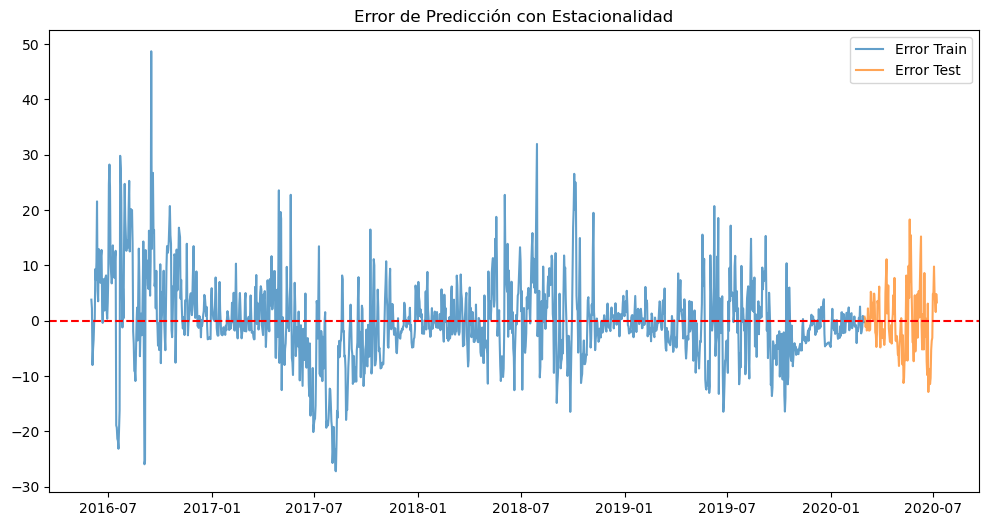

In [8]:
error_train_seasonal = y_train - y_pred_train_seasonal
error_test_seasonal = y_test - y_pred_test_seasonal

plt.figure(figsize=(12, 6))
plt.plot(train['date'], error_train_seasonal, label='Error Train', alpha=0.7)
plt.plot(test['date'], error_test_seasonal, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error de Predicción con Estacionalidad')
plt.show()

Como capturamos la componente estacional el error disminuye mucho

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [16]:
!pip install prophet

     ---------------------------------------- 0.0/50.0 kB ? eta -:--:--
     -------- ------------------------------- 10.2/50.0 kB ? eta -:--:--
     ------------------------------- ------ 41.0/50.0 kB 653.6 kB/s eta 0:00:01
     -------------------------------------- 50.0/50.0 kB 641.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.4/12.1 MB 12.2 MB/s eta 0:00:01
   ---- ----------------------------------- 1.2/12.1 MB 15.5 MB/s eta 0:00:01
   -------- ------------------------------- 2.6/12.1 MB 21.0 MB/s eta 0:00:01
   --------------- ------------------------ 4.8/12.1 MB 27.6 MB/s eta 0:00:01
   --------------------------- ------------ 8.3/12.1 MB 38.1 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 65.6 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 54.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/99.1 kB ? eta -:--:--
   ----

In [1]:
from prophet import Prophet

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Respuesta:**

13:07:00 - cmdstanpy - INFO - Chain [1] start processing
13:07:00 - cmdstanpy - INFO - Chain [1] done processing
13:07:00 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will retu

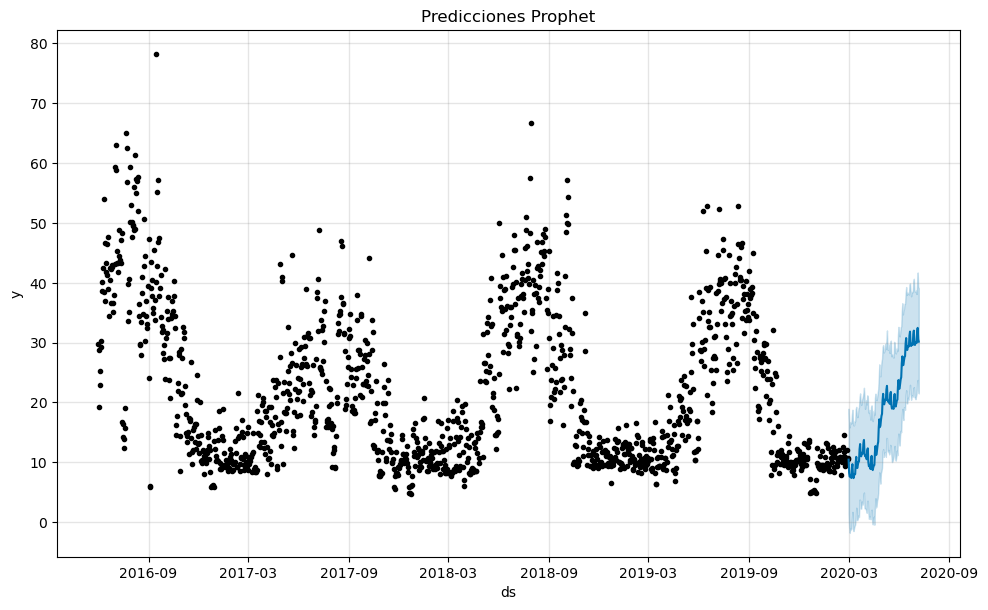

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



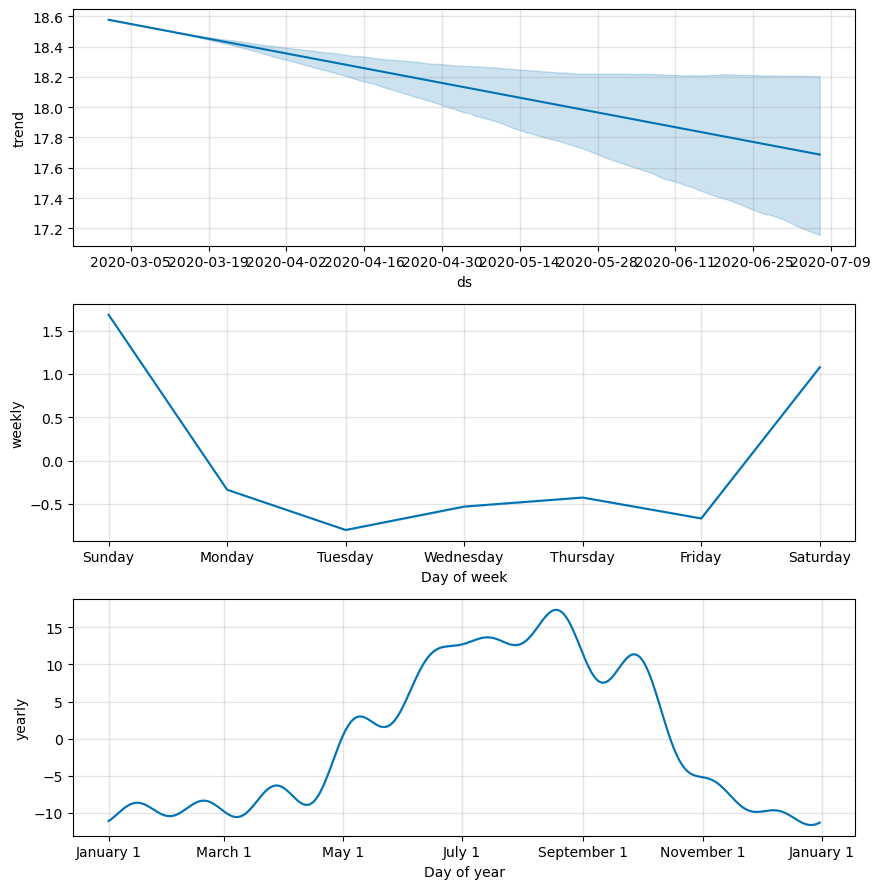

MAE Train Prophet: 4.8205
MAE Test Prophet: 4.9340


Text(0.5, 1.0, 'Error observado en las componentes de Prophet.')

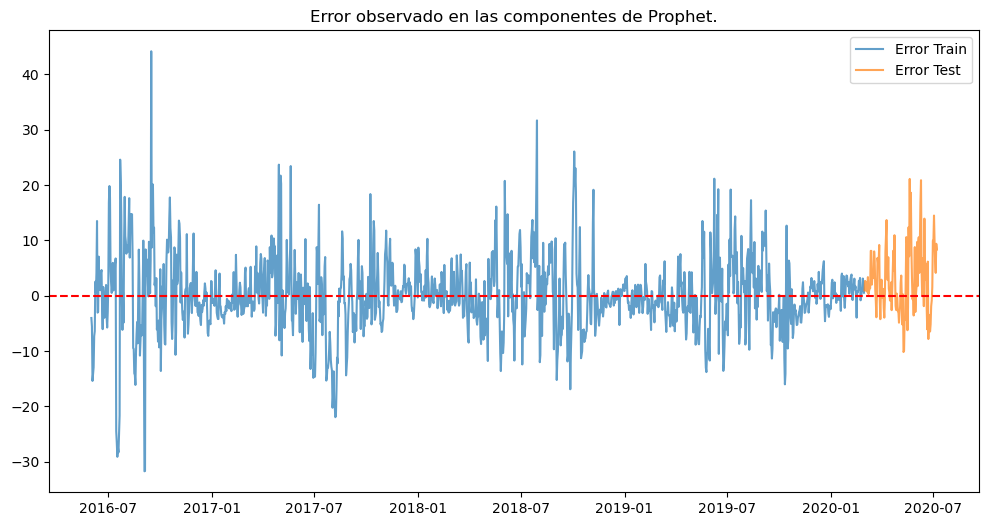

In [10]:
#1
train_prophet = train[['date', 'Energy_kWh']].copy()
test_prophet = test[['date', 'Energy_kWh']].copy()

train_prophet.columns = ['ds', 'y']
test_prophet.columns = ['ds', 'y']

model = Prophet()
model.fit(train_prophet)

future = test_prophet[['ds']].copy()
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title('Predicciones Prophet')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

forecast_train = model.predict(train_prophet[['ds']])

mae_train_prophet = mean_absolute_error(train_prophet['y'], forecast_train['yhat'])
mae_test_prophet = mean_absolute_error(test_prophet['y'], forecast['yhat'])

print(f'MAE Train Prophet: {mae_train_prophet:.4f}')
print(f'MAE Test Prophet: {mae_test_prophet:.4f}')

error_train_prophet = train_prophet['y'].values - forecast_train['yhat'].values
error_test_prophet = test_prophet['y'].values - forecast['yhat'].values

plt.figure(figsize=(12, 6))
plt.plot(train_prophet['ds'], error_train_prophet, label='Error Train', alpha=0.7)
plt.plot(test_prophet['ds'], error_test_prophet, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error observado en las componentes de Prophet.')

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

13:08:35 - cmdstanpy - INFO - Chain [1] start processing
13:08:36 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



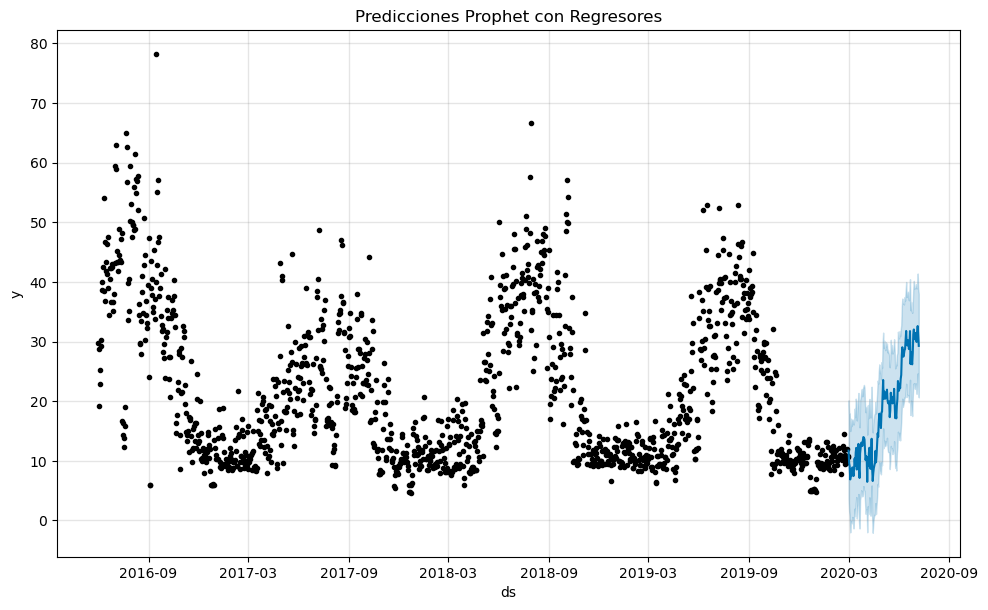

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_en

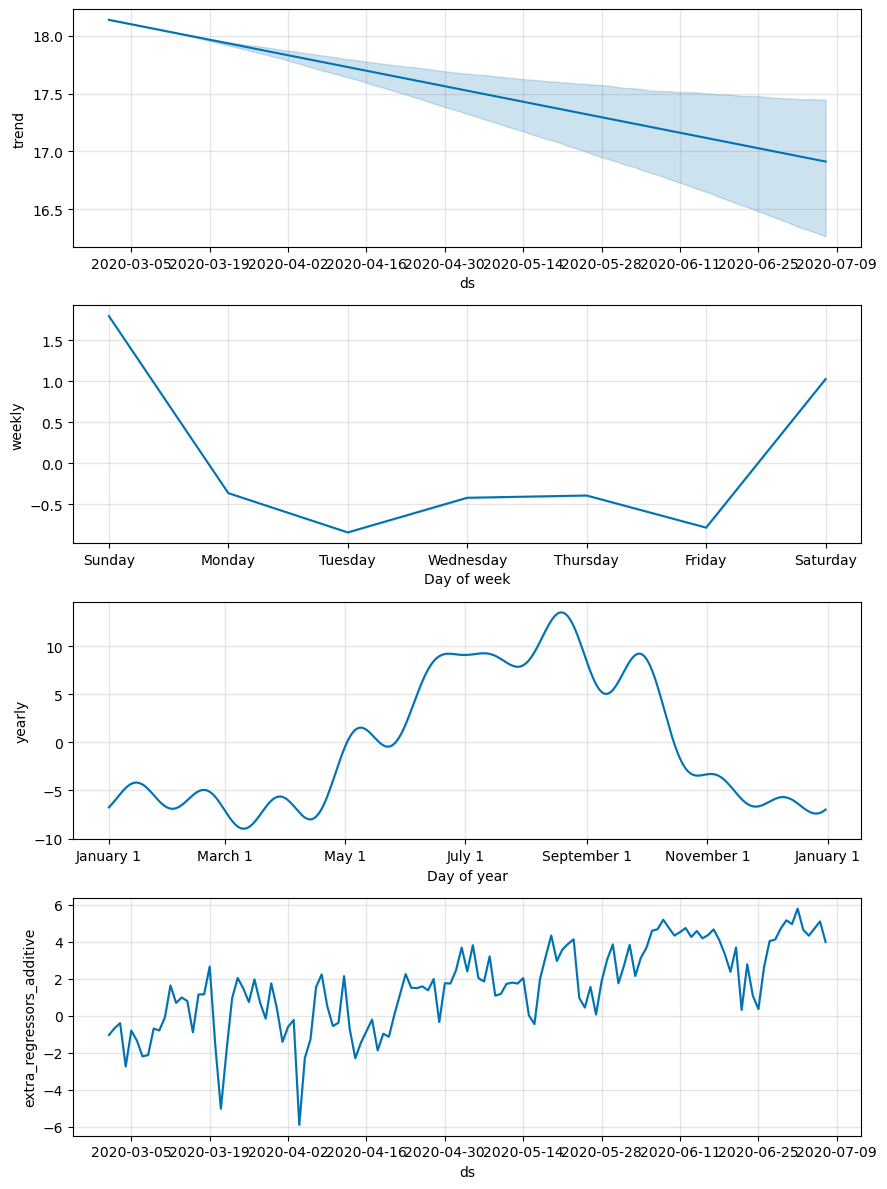

MAE Train con Regresores: 4.7168
MAE Test con Regresores: 4.5079
El modelo mejora con variables meteorológicas.


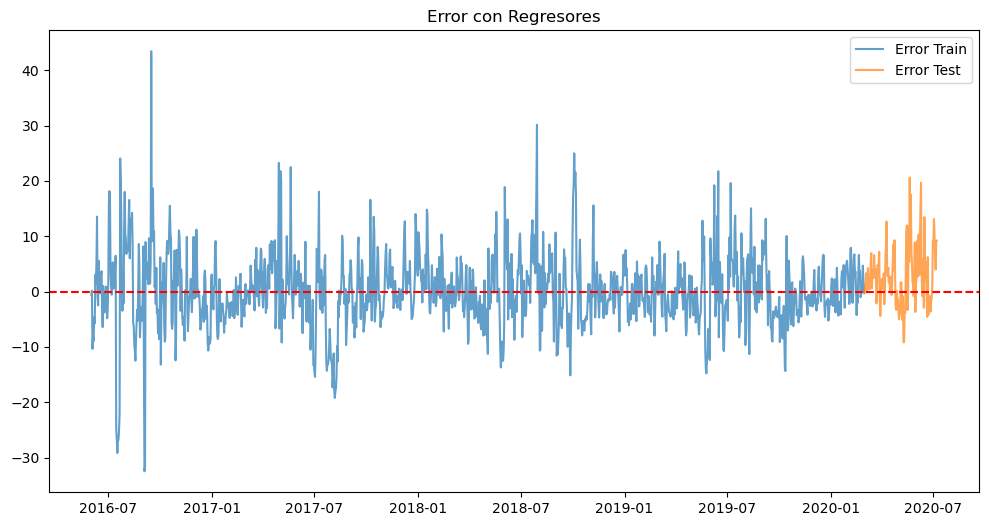

In [12]:
df_frink = pd.read_csv('datos_frink.csv')
df_frink['date'] = pd.to_datetime(df_frink['date'])

regressors = ['Temp_avg', 'Dew_avg', 'Hum_avg', 'Wind_avg', 'Press_avg']

train_reg = train[['date', 'Energy_kWh']].merge(df_frink[['date'] + regressors], on='date')
test_reg = test[['date', 'Energy_kWh']].merge(df_frink[['date'] + regressors], on='date')

train_reg.columns = ['ds', 'y'] + regressors
test_reg.columns = ['ds', 'y'] + regressors

model_reg = Prophet()
for reg in regressors:
    model_reg.add_regressor(reg)

model_reg.fit(train_reg)

future_reg = test_reg[['ds'] + regressors].copy()
forecast_reg = model_reg.predict(future_reg)

fig1 = model_reg.plot(forecast_reg)
plt.title('Predicciones Prophet con Regresores')
plt.show()

fig2 = model_reg.plot_components(forecast_reg)
plt.show()

forecast_train_reg = model_reg.predict(train_reg[['ds'] + regressors])

mae_train_reg = mean_absolute_error(train_reg['y'], forecast_train_reg['yhat'])
mae_test_reg = mean_absolute_error(test_reg['y'], forecast_reg['yhat'])

print(f'MAE Train con Regresores: {mae_train_reg:.4f}')
print(f'MAE Test con Regresores: {mae_test_reg:.4f}')
print('El modelo mejora con variables meteorológicas.')

error_train_reg = train_reg['y'].values - forecast_train_reg['yhat'].values
error_test_reg = test_reg['y'].values - forecast_reg['yhat'].values

plt.figure(figsize=(12, 6))
plt.plot(train_reg['ds'], error_train_reg, label='Error Train', alpha=0.7)
plt.plot(test_reg['ds'], error_test_reg, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error con Regresores')
plt.show()

Si hay estacionalidad, las variables metereológicas mejoran notablemente el rendimiento (aprox 0.4 en MAE de test)

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

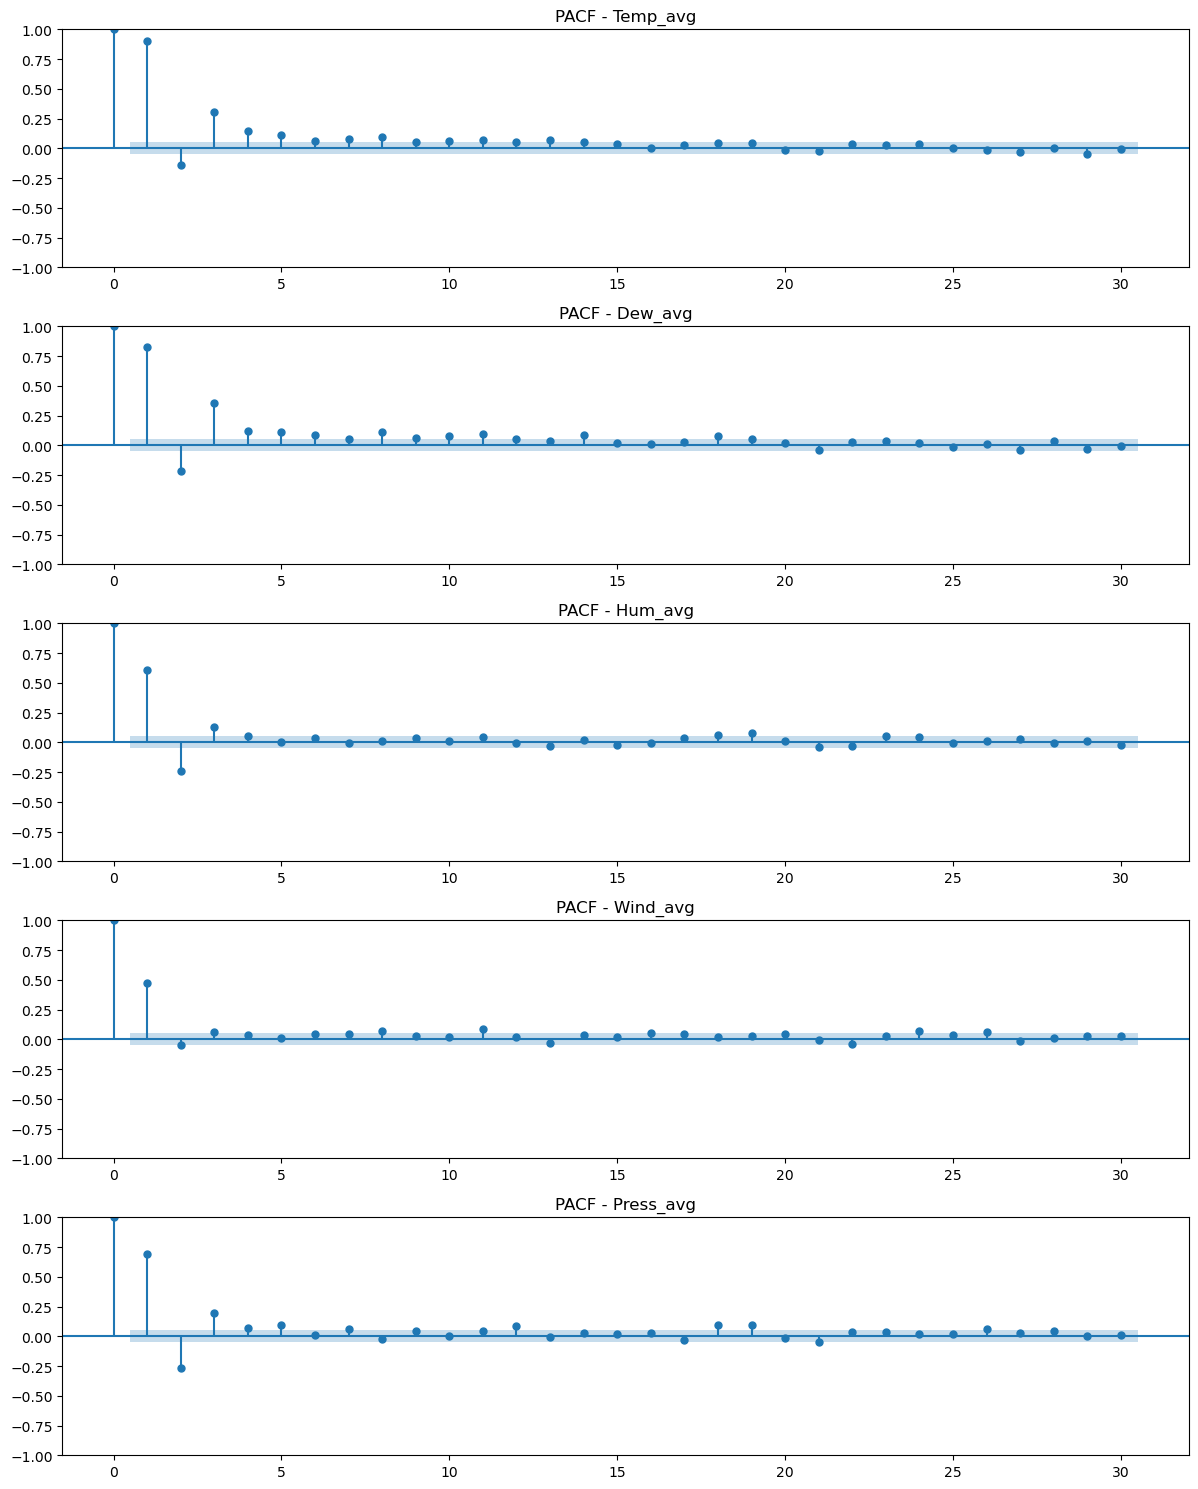

In [13]:
from statsmodels.graphics.tsaplots import plot_pacf

df_full = df_energia.merge(df_frink, on='date')

fig, axes = plt.subplots(len(regressors), 1, figsize=(12, 15))
for i, reg in enumerate(regressors):
    plot_pacf(df_full[reg].dropna(), lags=30, ax=axes[i])
    axes[i].set_title(f'PACF - {reg}')
plt.tight_layout()
plt.show()

Elegimos 4 lags porque en las variables seleccionadas la correlación es significativa más o menos hasta el cuarto paso anterior

15:08:56 - cmdstanpy - INFO - Chain [1] start processing
15:08:56 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



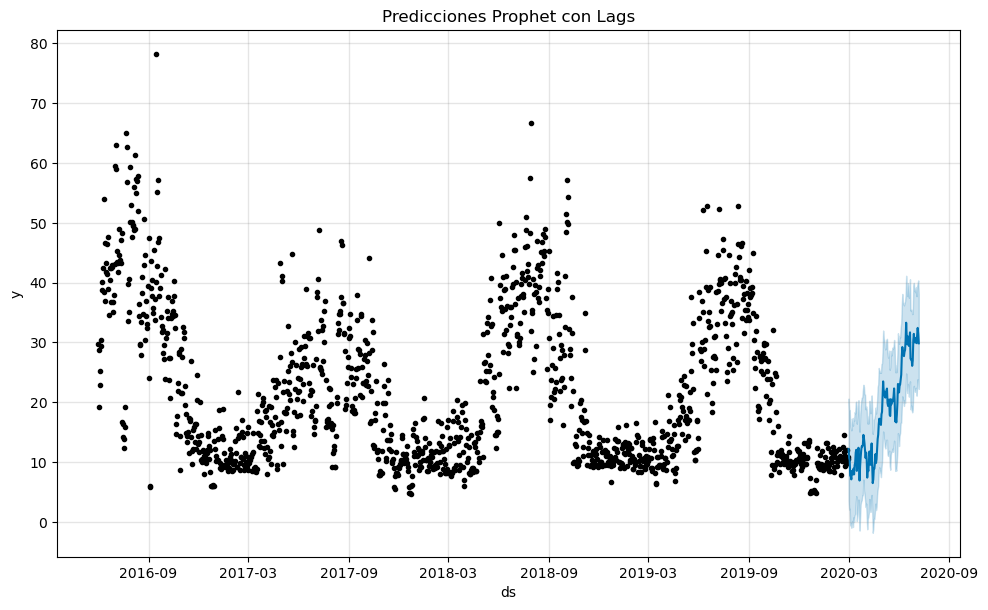

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_en

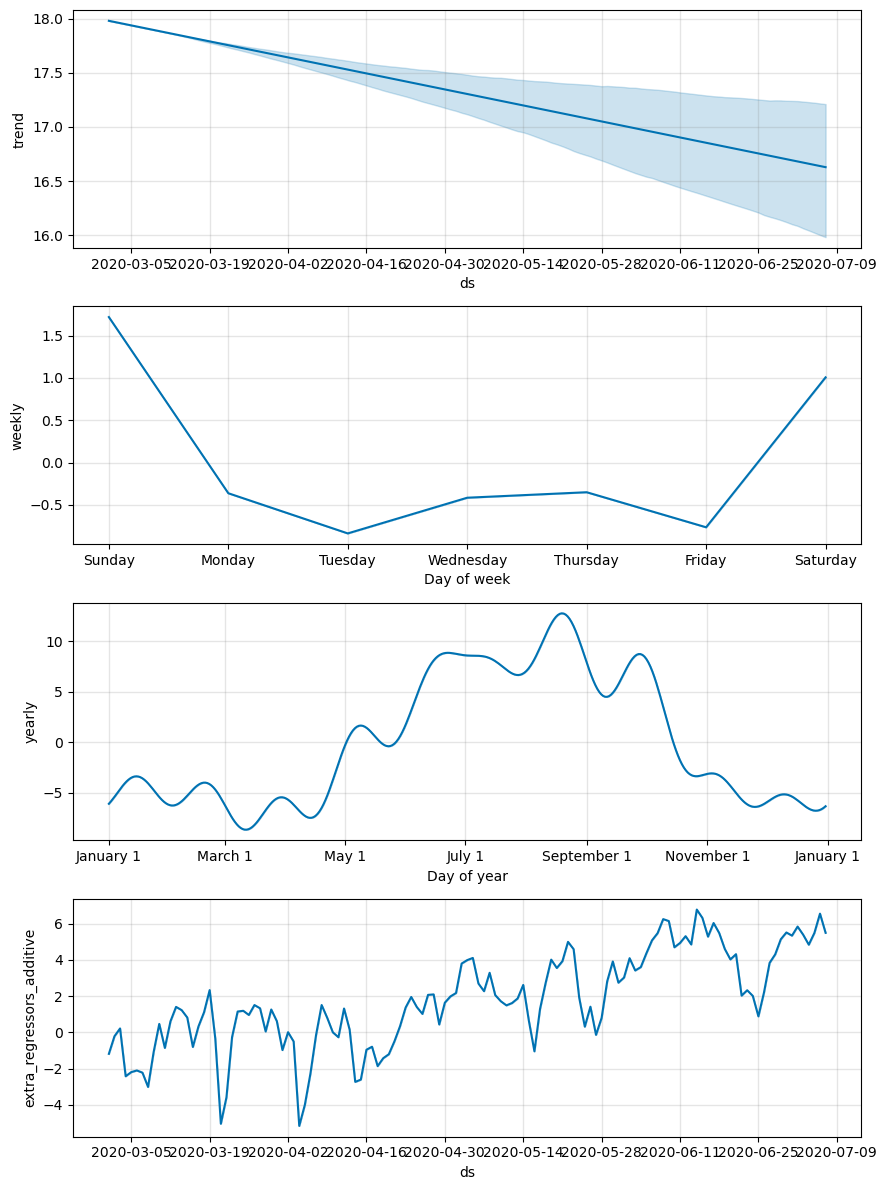

MAE Train con Lags: 4.6758
MAE Test con Lags: 4.4706
Los lags mejoran el desempeño del modelo.


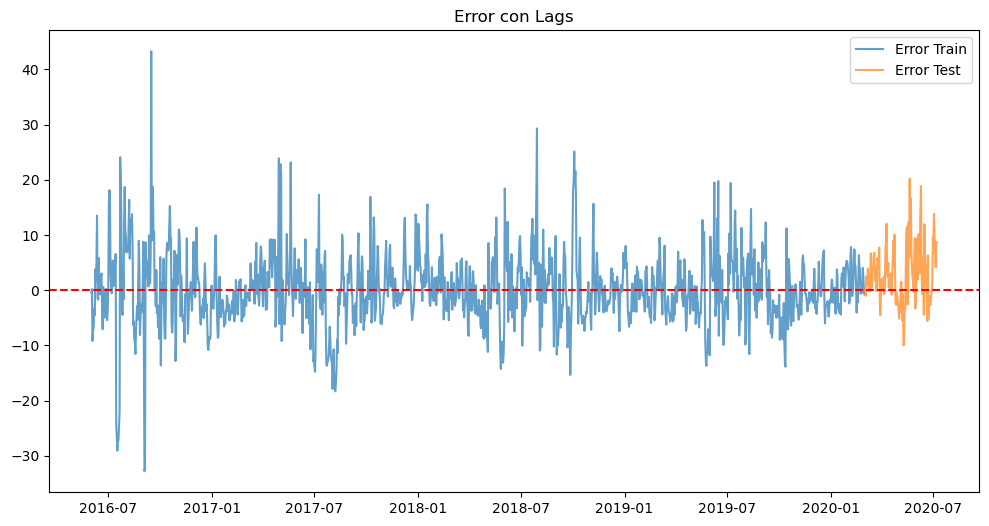

In [15]:
lags_to_use = 4

train_lags = train_reg.copy()
test_lags = test_reg.copy()

for reg in regressors:
    df_full_reg = df_full[['date', reg]].copy()
    for lag in range(1, lags_to_use + 1):
        df_full_reg[f'{reg}_lag{lag}'] = df_full_reg[reg].shift(lag)
    
    train_lags = train_lags.merge(df_full_reg, left_on='ds', right_on='date', how='left')
    test_lags = test_lags.merge(df_full_reg, left_on='ds', right_on='date', how='left')
    
    train_lags = train_lags.drop(columns=['date', reg + '_x'])
    test_lags = test_lags.drop(columns=['date', reg + '_x'])
    train_lags = train_lags.rename(columns={reg + '_y': reg})
    test_lags = test_lags.rename(columns={reg + '_y': reg})

lag_columns = [col for col in train_lags.columns if 'lag' in col]

for col in lag_columns:
    train_lags[col] = train_lags[col].fillna(train_lags[col].mean())
    test_lags[col] = test_lags[col].fillna(test_lags[col].mean())

model_lags = Prophet()
for reg in regressors:
    model_lags.add_regressor(reg)
for lag_col in lag_columns:
    model_lags.add_regressor(lag_col)

model_lags.fit(train_lags)

forecast_lags = model_lags.predict(test_lags)

fig1 = model_lags.plot(forecast_lags)
plt.title('Predicciones Prophet con Lags')
plt.show()

fig2 = model_lags.plot_components(forecast_lags)
plt.show()

forecast_train_lags = model_lags.predict(train_lags)

mae_train_lags = mean_absolute_error(train_lags['y'], forecast_train_lags['yhat'])
mae_test_lags = mean_absolute_error(test_lags['y'], forecast_lags['yhat'])

print(f'MAE Train con Lags: {mae_train_lags:.4f}')
print(f'MAE Test con Lags: {mae_test_lags:.4f}')
print('Los lags mejoran el desempeño del modelo.')

error_train_lags = train_lags['y'].values - forecast_train_lags['yhat'].values
error_test_lags = test_lags['y'].values - forecast_lags['yhat'].values

plt.figure(figsize=(12, 6))
plt.plot(train_lags['ds'], error_train_lags, label='Error Train', alpha=0.7)
plt.plot(test_lags['ds'], error_test_lags, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error con Lags')
plt.show()

Si existe un comportamiento estacional en la serie y nuevamente hubo una mejora al añadir el lag, pero esta vez fue menor (aprox 0.1 en MAE de test)

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [16]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [17]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative'],
    'changepoint_range': [0.8, 0.9]
}

features_list = regressors + lag_columns

tuning_results, best_params = optimize_prophet(train_lags, test_lags, features_list, param_grid)

print('Best Parameters:', best_params)

Tuning Prophet parameters: 100%|██████████| 64/64 [01:29<00:00,  1.40s/it]

Best Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8}


c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



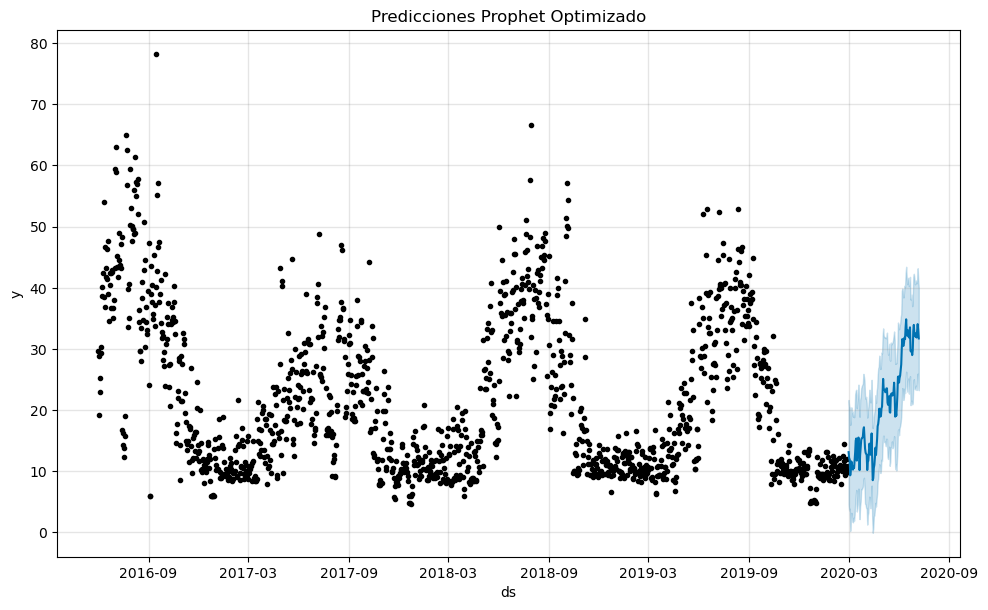

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_env\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\Users\potat\anaconda3\envs\cuda_en

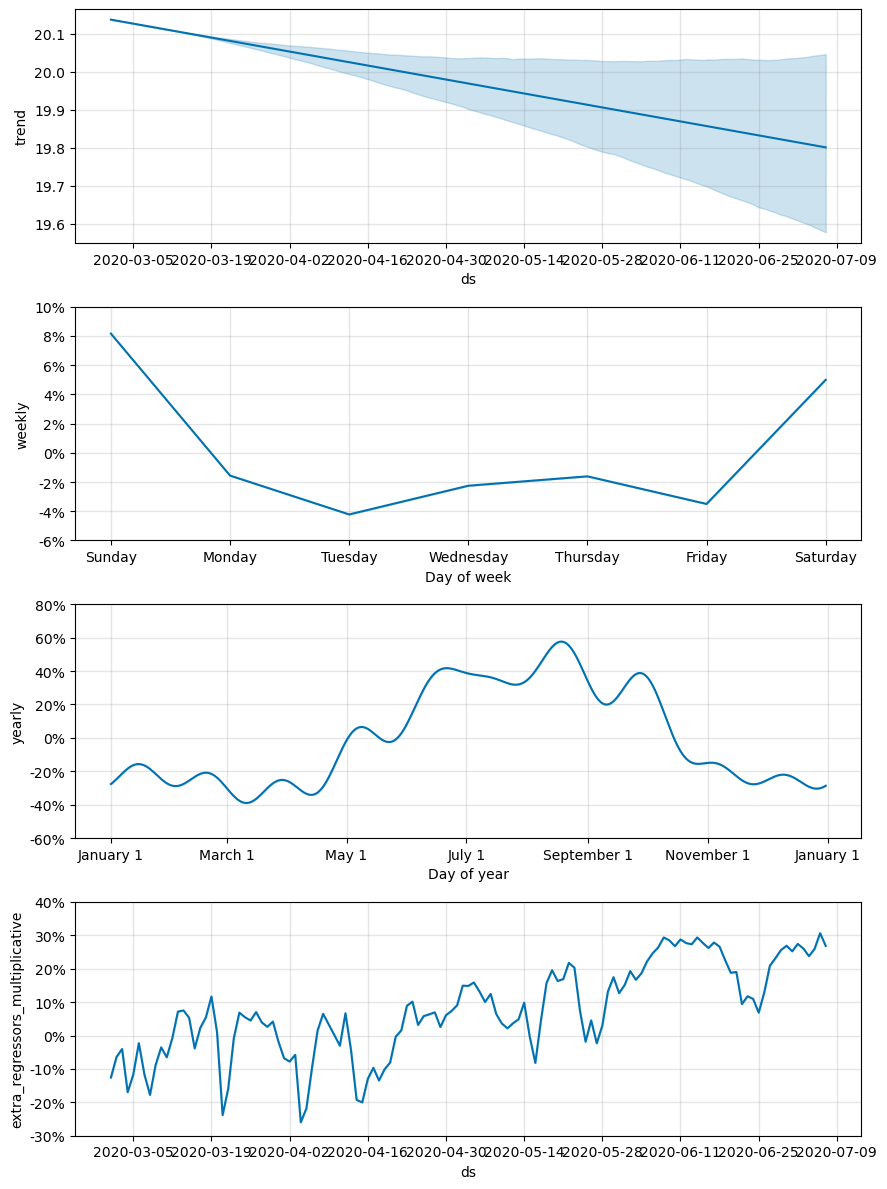

MAE Train Optimizado: 4.8058
MAE Test Optimizado: 3.9814


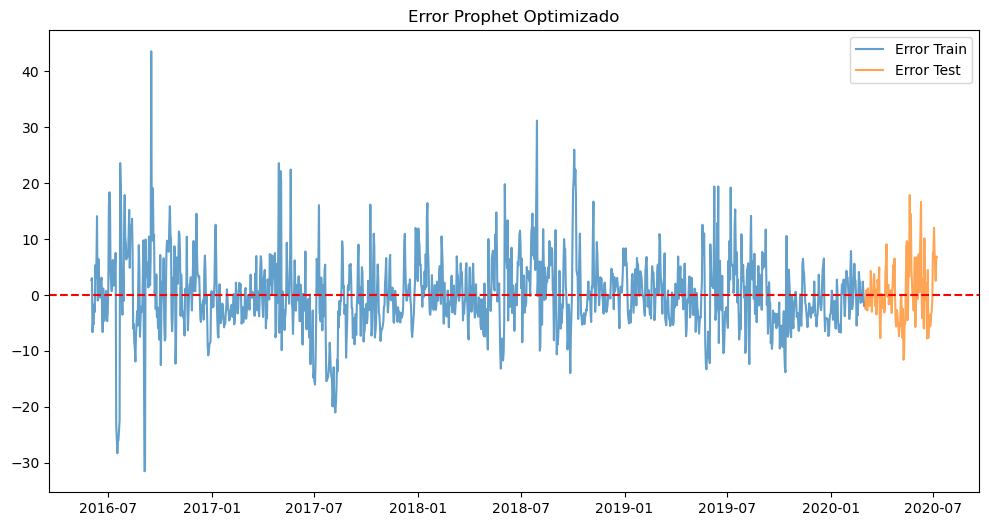

In [18]:
model_optimized = Prophet(**best_params)
for feature in features_list:
    model_optimized.add_regressor(feature)

model_optimized.fit(train_lags)

forecast_optimized = model_optimized.predict(test_lags)

fig1 = model_optimized.plot(forecast_optimized)
plt.title('Predicciones Prophet Optimizado')
plt.show()

fig2 = model_optimized.plot_components(forecast_optimized)
plt.show()

forecast_train_optimized = model_optimized.predict(train_lags)

mae_train_optimized = mean_absolute_error(train_lags['y'], forecast_train_optimized['yhat'])
mae_test_optimized = mean_absolute_error(test_lags['y'], forecast_optimized['yhat'])

print(f'MAE Train Optimizado: {mae_train_optimized:.4f}')
print(f'MAE Test Optimizado: {mae_test_optimized:.4f}')

error_train_optimized = train_lags['y'].values - forecast_train_optimized['yhat'].values
error_test_optimized = test_lags['y'].values - forecast_optimized['yhat'].values

plt.figure(figsize=(12, 6))
plt.plot(train_lags['ds'], error_train_optimized, label='Error Train', alpha=0.7)
plt.plot(test_lags['ds'], error_test_optimized, label='Error Test', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.legend()
plt.title('Error Prophet Optimizado')
plt.show()

Este modelo optimizado mejora el MAE significativamente, esto es importante pues para este test se usaron pocas combinaciones de hierparámetros y podría ser aún mayor la mejora con más poder de computo o más tiempo.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [ ]:
#!pip install surprise

In [19]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [20]:
df_cervezas = pd.read_csv('cervezas.csv')

print("Información del dataset:")
print(df_cervezas.info())
print("\nPrimeras filas:")
print(df_cervezas.head())
print("\nValores nulos:")
print(df_cervezas.isnull().sum())
print(f"\nCantidad de cervezas únicas: {df_cervezas['beerId'].nunique()}")
print(f"Cantidad de ciudadanos: {df_cervezas['userId'].nunique()}")
print(f"Total de evaluaciones: {len(df_cervezas)}")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295059 entries, 0 to 295058
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     295059 non-null  int64  
 1   beerId     295059 non-null  int64  
 2   rating     295059 non-null  float64
 3   beerName   295059 non-null  object 
 4   beerStyle  295059 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.3+ MB
None

Primeras filas:
   userId  beerId  rating                            beerName  \
0     144     995     3.0                            Mai Bock   
1      63   58695     4.0  Hop In The Dark Cascadian Dark Ale   
2     147    4083     5.0                 Stone Ruination IPA   
3    4261   40310     3.0                     Noël Des Géants   
4     140    1904     5.0       Sierra Nevada Celebration Ale   

                        beerStyle  
0           Maibock / Helles Bock  
1              American Black 

## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

Usuarios: 706
Productos: 3747
Calificaciones: 295059
Calificaciones faltantes: 2350323
Media de calificaciones: 3.86


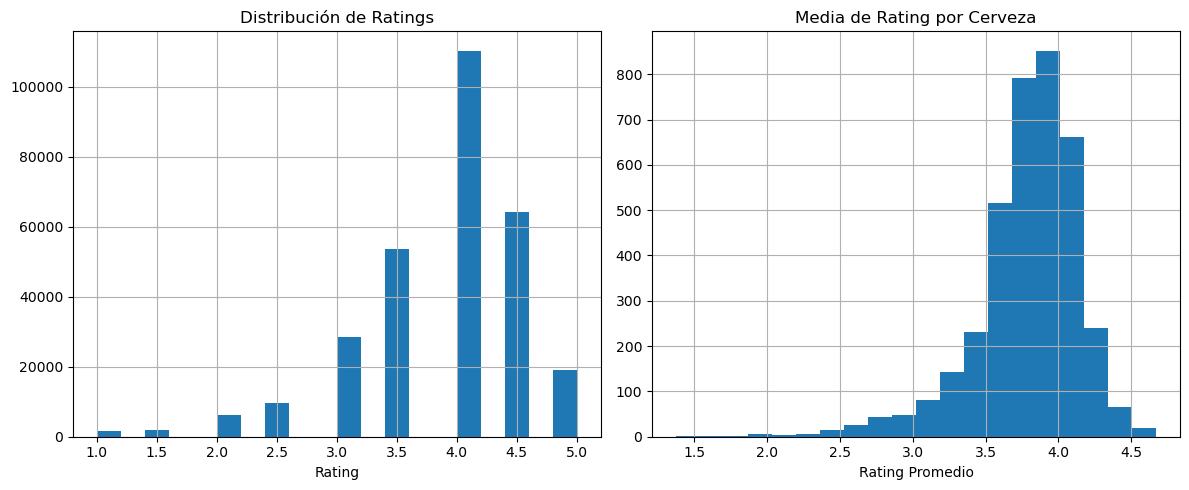


Matriz Usuario-Producto:
beerId  5         6         7         9         10        11        14     \
userId                                                                      
1         NaN       NaN       NaN       NaN       NaN       NaN       NaN   
3       3.395  3.765217  3.256849  3.478261       NaN       NaN       NaN   
4         NaN       NaN       NaN       NaN  3.791908       NaN       NaN   
5         NaN       NaN       NaN       NaN       NaN  3.431818       NaN   
6         NaN       NaN       NaN       NaN       NaN       NaN  3.892157   

beerId  15     17     19     ...  74491  74530  74548  74579  74634  74827  \
userId                       ...                                             
1         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
3         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
4         NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN   
5         NaN    NaN    NaN  ...    NaN    N

In [21]:
n_users = df_cervezas['userId'].nunique()
n_products = df_cervezas['beerId'].nunique()
n_ratings = len(df_cervezas)
n_missing = n_users * n_products - n_ratings

print(f"Usuarios: {n_users}")
print(f"Productos: {n_products}")
print(f"Calificaciones: {n_ratings}")
print(f"Calificaciones faltantes: {n_missing}")
print(f"Media de calificaciones: {df_cervezas['rating'].mean():.2f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_cervezas['rating'].hist(bins=20)
plt.title('Distribución de Ratings')
plt.xlabel('Rating')

plt.subplot(1, 2, 2)
beer_avg = df_cervezas.groupby('beerId')['rating'].mean()
beer_avg.hist(bins=20)
plt.title('Media de Rating por Cerveza')
plt.xlabel('Rating Promedio')
plt.tight_layout()
plt.show()

user_item_matrix = df_cervezas.pivot_table(index='userId', columns='beerId', values='rating')
print("\nMatriz Usuario-Producto:")
print(user_item_matrix.head())

## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [23]:
#1
df_beers = df_cervezas[['beerId', 'beerName', 'beerStyle']].drop_duplicates().reset_index(drop=True)

#2
vectorizer = CountVectorizer(lowercase=True, stop_words='english', min_df=10)
bow_matrix = vectorizer.fit_transform(df_beers['beerStyle'])
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nBag of Words:")
print(bow_df.head())

#3
cosine_sim = cosine_similarity(bow_matrix)

def get_similar_beers(beer_name, top_n=5):
    idx = df_beers[df_beers['beerName'] == beer_name].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    beer_indices = [i[0] for i in sim_scores]
    print(f"\nTop {top_n} cervezas similares a '{beer_name}':")
    for i, idx in enumerate(beer_indices, 1):
        print(f"{i}. {df_beers.iloc[idx]['beerName']} (Similarity: {sim_scores[i-1][1]:.4f})")
    return df_beers.iloc[beer_indices][['beerName', 'beerStyle']]

get_similar_beers('Chocolate Porter', top_n=5)

#4
carl_beers = df_cervezas[df_cervezas['userId'] == 100].sort_values('rating', ascending=False)
best_beer_carl = carl_beers.iloc[0]['beerName']
print(f"\nMejor cerveza evaluada por Carl: {best_beer_carl} (Rating: {carl_beers.iloc[0]['rating']})")

get_similar_beers(best_beer_carl, top_n=5)


Bag of Words:
   adjunct  ale  altbier  amber  american  apa  baltic  barleywine  beer  \
0        0    0        0      0         0    0       0           0     0   
1        0    1        0      0         1    0       0           0     0   
2        0    0        0      0         1    0       0           0     0   
3        0    0        0      0         0    0       0           0     1   
4        0    0        0      0         1    0       0           0     0   

   belgian  ...  vienna  warmer  wee  weizenbock  wheat  wheatwine  wild  \
0        0  ...       0       0    0           0      0          0     0   
1        0  ...       0       0    0           0      0          0     0   
2        0  ...       0       0    0           0      0          0     0   
3        0  ...       0       0    0           0      0          0     0   
4        0  ...       0       0    0           0      0          0     0   

   winter  witbier  zwickel  
0       0        0        0  
1       0  

,beerName,beerStyle
112,Grail Ale,American Amber / Red Ale
119,Santa's Private Reserve Ale,American Amber / Red Ale
122,Hemp Hop Rye Amber Ale,American Amber / Red Ale
207,Autumn Fest,American Amber / Red Ale
305,Red Rocket Ale,American Amber / Red Ale


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

In [25]:
#1
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_cervezas[['userId', 'beerId', 'rating']], reader)

No importa el orden en surprise porque crea un conjunto pares y los indexa sin guardar el orden que pusimos

In [26]:
from surprise.model_selection import train_test_split

#2
trainset, testset = train_test_split(data, test_size=0.3, random_state=42)

#3
knn_user = KNNBasic(sim_options={'name': 'cosine', 'user_based': True})
knn_user.fit(trainset)
predictions_knn_user = knn_user.test(testset)

#4
mae_knn_user = mae(predictions_knn_user)
print(f'MAE KNN Usuario: {mae_knn_user:.4f}')

predictions_df_user = pd.DataFrame(predictions_knn_user, columns=['uid', 'iid', 'r_ui', 'est', 'details'])
print("\nPredicciones KNN Usuario:")
print(predictions_df_user.head(10))

#5
knn_item = KNNBasic(sim_options={'name': 'cosine', 'user_based': False})
knn_item.fit(trainset)
predictions_knn_item = knn_item.test(testset)

mae_knn_item = mae(predictions_knn_item)
print(f'\nMAE KNN Producto: {mae_knn_item:.4f}')

predictions_df_item = pd.DataFrame(predictions_knn_item, columns=['uid', 'iid', 'r_ui', 'est', 'details'])
print("\nPredicciones KNN Producto:")
print(predictions_df_item.head(10))

Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE:  0.4639
MAE KNN Usuario: 0.4639

Predicciones KNN Usuario:
     uid    iid  r_ui       est                                    details
0   1628   9755   4.5  4.200000  {'actual_k': 40, 'was_impossible': False}
1    187    601   2.0  3.825000  {'actual_k': 40, 'was_impossible': False}
2    112    409   3.0  3.862500  {'actual_k': 40, 'was_impossible': False}
3    738   5051   4.0  4.027027  {'actual_k': 37, 'was_impossible': False}
4    141   4394   4.0  3.887500  {'actual_k': 40, 'was_impossible': False}
5  10099  18862   4.0  3.800000  {'actual_k': 40, 'was_impossible': False}
6     28     61   3.0  4.100000  {'actual_k': 40, 'was_impossible': False}
7     22     33   3.0  4.125000  {'actual_k': 40, 'was_impossible': False}
8   2681  48139   4.0  3.825000  {'actual_k': 40, 'was_impossible': False}
9    345   1013   4.5  3.900000  {'actual_k': 40, 'was_impossible': False}
Computing the cosine similarity mat

Los MAE en ambos casos son casi identicos, asi que en este problema sea mejor usar los datos a los que se tenga acceso más rápido para evitar cold start o los datos que sean mejores a nivel de privacidad del usuario.

### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [27]:
RANDOM_STATE = 10

#1
nmf = NMF(random_state=RANDOM_STATE)
nmf.fit(trainset)
predictions_nmf = nmf.test(testset)

#2
mae_nmf = mae(predictions_nmf)
print(f'MAE NMF: {mae_nmf:.4f}')

predictions_df_nmf = pd.DataFrame(predictions_nmf, columns=['uid', 'iid', 'r_ui', 'est', 'details'])
print("\nPredicciones NMF:")
print(predictions_df_nmf.head(10))

#3
svd = SVD(random_state=RANDOM_STATE)
svd.fit(trainset)
predictions_svd = svd.test(testset)

#4
mae_svd = mae(predictions_svd)
print(f'\nMAE SVD: {mae_svd:.4f}')

predictions_df_svd = pd.DataFrame(predictions_svd, columns=['uid', 'iid', 'r_ui', 'est', 'details'])
print("\nPredicciones SVD:")
print(predictions_df_svd.head(10))

print("COMPARACIÓN DE LOS MODELOS:")
print(f"KNN Usuario: {mae_knn_user:.4f}")
print(f"KNN Producto: {mae_knn_item:.4f}")
print(f"NMF: {mae_nmf:.4f}")
print(f"SVD: {mae_svd:.4f}")

best_model_name = min([('KNN Usuario', mae_knn_user), ('KNN Producto', mae_knn_item), 
                        ('NMF', mae_nmf), ('SVD', mae_svd)], key=lambda x: x[1])[0]
print(f"\nMejor modelo: {best_model_name}")

MAE:  0.4802
MAE NMF: 0.4802

Predicciones NMF:
     uid    iid  r_ui       est                    details
0   1628   9755   4.5  3.927795  {'was_impossible': False}
1    187    601   2.0  3.912118  {'was_impossible': False}
2    112    409   3.0  3.744746  {'was_impossible': False}
3    738   5051   4.0  4.018643  {'was_impossible': False}
4    141   4394   4.0  3.849517  {'was_impossible': False}
5  10099  18862   4.0  4.058351  {'was_impossible': False}
6     28     61   3.0  4.114440  {'was_impossible': False}
7     22     33   3.0  4.086996  {'was_impossible': False}
8   2681  48139   4.0  3.856951  {'was_impossible': False}
9    345   1013   4.5  4.044712  {'was_impossible': False}
MAE:  0.4610

MAE SVD: 0.4610

Predicciones SVD:
     uid    iid  r_ui       est                    details
0   1628   9755   4.5  4.026153  {'was_impossible': False}
1    187    601   2.0  3.805831  {'was_impossible': False}
2    112    409   3.0  3.881893  {'was_impossible': False}
3    738   5051   

SVD generalmente ofrece el mejor balance entre precisión y generalización normalmente, además en este caso podemos ver que ofrece el mejor rendimiento absoluto pues presenta un menor error de tipo MAE.

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [28]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [29]:
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        user_ratings_unique = []
        seen = set()
        for iid, est in user_ratings:
            if iid not in seen:
                user_ratings_unique.append((iid, est))
                seen.add(iid)
        top_n[uid] = user_ratings_unique[:n]
    
    return top_n

top_n_svd = get_top_n(predictions_svd, n=3)

for i, (beer_id, rating) in enumerate(top_n_svd[100], 1):
    beer_name = df_cervezas[df_cervezas['beerId'] == beer_id]['beerName'].iloc[0]
    print(f"{i}. {beer_name} (ID: {beer_id}, Est. Rating: {rating:.2f})")

1. McNeill's Firehouse Amber Ale (ID: 325, Est. Rating: 3.94)
2. McNeill's Extra Special Bitter (ID: 1393, Est. Rating: 3.93)
3. McNeill's Dead Horse IPA (ID: 1884, Est. Rating: 3.76)


In [33]:
carl_rated = df_cervezas[df_cervezas['userId'] == 100]['beerId'].values
all_beers = df_cervezas['beerId'].unique()
carl_unrated = [b for b in all_beers if b not in carl_rated]

random_beers = np.random.choice(carl_unrated, 5, replace=False)
print(f"5 cervezas aleatorias no evaluadas por Carl:")
for beer_id in random_beers:
    pred = svd.predict(100, beer_id)
    beer_name = df_cervezas[df_cervezas['beerId'] == beer_id]['beerName'].iloc[0]
    print(f"  {beer_name} (ID: {beer_id}) Calificacion estimada: {pred.est:.2f}")

5 cervezas aleatorias no evaluadas por Carl:
  Seriously Bad Elf (ID: 26887) Calificacion estimada: 3.69
  Winter Warmer (ID: 33822) Calificacion estimada: 3.88
  Rye Hopper (ID: 44968) Calificacion estimada: 3.81
  Gossamer Golden Ale (ID: 54770) Calificacion estimada: 3.79
  Hophead India Pale Ale (ID: 8012) Calificacion estimada: 3.84


In [ ]:
precisions, recalls = precision_recall_at_k(predictions_svd, k=10, threshold=3.5)
precision_avg = np.mean(list(precisions.values()))
recall_avg = np.mean(list(recalls.values()))

print(f"\nPrecision@10: {precision_avg:.4f}")
print(f"Recall@10: {recall_avg:.4f}")


Precision@10: 0.7433
Recall@10: 0.3398


Es un modelo un poco desbalanceado pero aceptable por que tiene una prescision alta lo que significa que bastantes de los que tomo verdaderos son efectivamente verdaderos lo que es importante en recomendación. (No tanto el recall pues basta tomar casos que son verdaderos y no es necesario tomarlos todos)

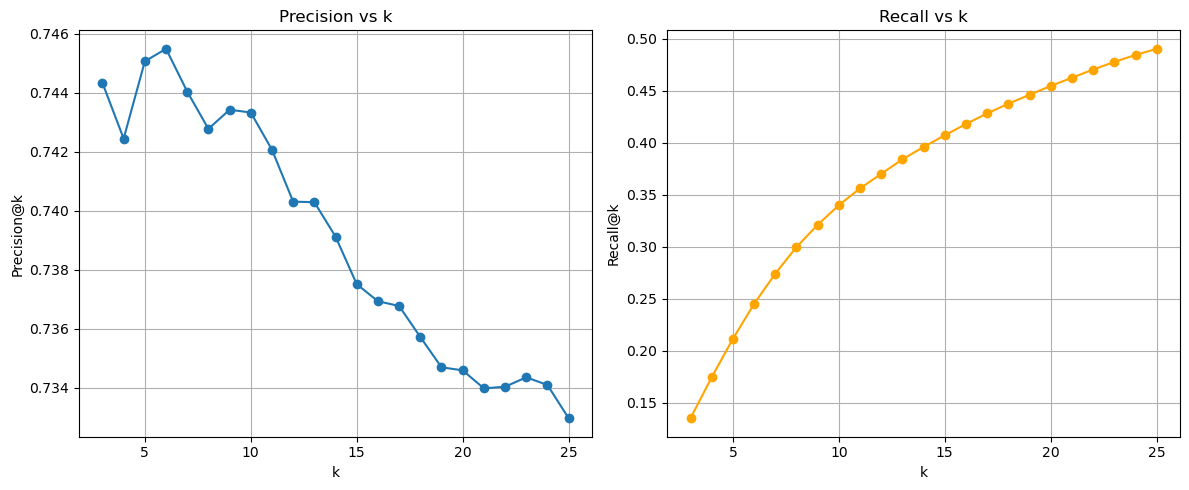

In [35]:
k_values = range(3, 26)
precisions_k = []
recalls_k = []

for k in k_values:
    prec, rec = precision_recall_at_k(predictions_svd, k=k, threshold=3.5)
    precisions_k.append(np.mean(list(prec.values())))
    recalls_k.append(np.mean(list(rec.values())))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, precisions_k, marker='o')
plt.xlabel('k')
plt.ylabel('Precision@k')
plt.title('Precision vs k')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, recalls_k, marker='o', color='orange')
plt.xlabel('k')
plt.ylabel('Recall@k')
plt.title('Recall vs k')
plt.grid(True)
plt.tight_layout()
plt.show()

Precision disminuye y Recall aumenta al aumentar el k, esto porque al tomar más valores, es más probable tomar más de los que realmente son positivos, aumentando el Recall, pero también más casos negativos como falsos, disminuyendo el Precision

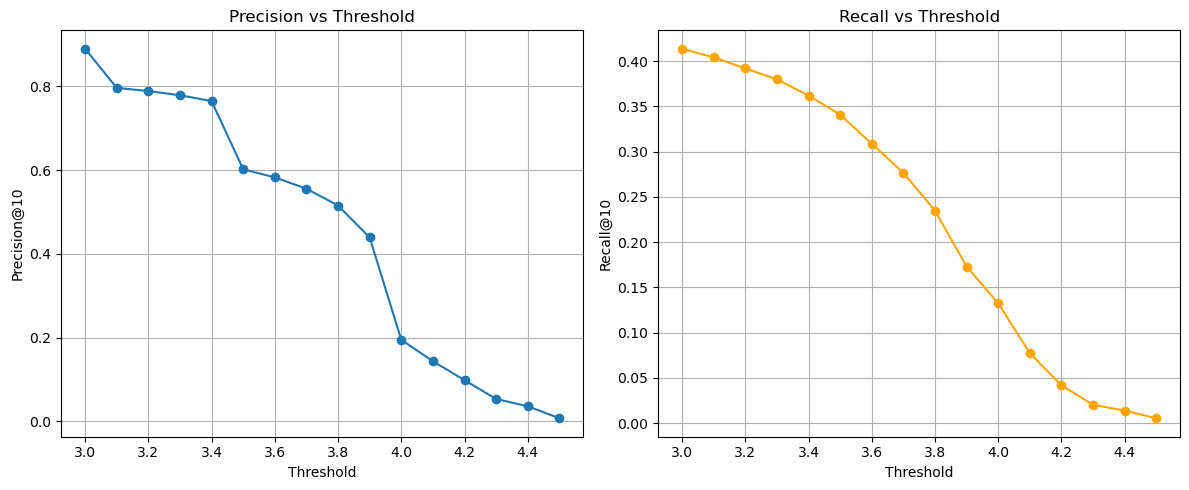

In [36]:
threshold_values = np.arange(3.0, 4.6, 0.1)
precisions_t = []
recalls_t = []

for t in threshold_values:
    prec, rec = precision_recall_at_k(predictions_svd, k=10, threshold=t)
    precisions_t.append(np.mean(list(prec.values())))
    recalls_t.append(np.mean(list(rec.values())))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(threshold_values, precisions_t, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Precision@10')
plt.title('Precision vs Threshold')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(threshold_values, recalls_t, marker='o', color='orange')
plt.xlabel('Threshold')
plt.ylabel('Recall@10')
plt.title('Recall vs Threshold')
plt.grid(True)
plt.tight_layout()
plt.show()

Ambas métricas disminuyen al aumentar el treshold más alto lo que es normal pues estoy haciendo más estricto lo que considero como bueno.

In [37]:
all_users = df_cervezas['userId'].unique()
all_items = df_cervezas['beerId'].unique()

complete_matrix = pd.DataFrame(index=all_users, columns=all_items)

for user in all_users:
    for item in all_items:
        pred = svd.predict(user, item)
        complete_matrix.loc[user, item] = pred.est

complete_matrix = complete_matrix.astype(float)
print("\nMatriz Usuario-Producto Completa:")
print(complete_matrix.head())
print(f"\nDimensiones: {complete_matrix.shape}")
print(f"Valores nulos: {complete_matrix.isnull().sum().sum()}")


Matriz Usuario-Producto Completa:
         995       58695     4083      40310     1904      409       16858  \
144   3.871923  3.781462  3.916896  3.748275  3.897678  3.854907  3.757748   
63    4.131765  4.036385  4.221171  4.013962  4.262591  4.096517  4.083995   
147   3.985632  3.902152  4.085296  3.885149  4.105790  3.957957  3.924880   
4261  3.739646  3.603304  3.880007  3.654779  3.886258  3.762138  3.779314   
140   4.043143  3.958659  4.145169  3.938711  4.173653  4.005133  3.987703   

         25061     14309     13906  ...     1145      708       45308  \
144   3.710735  3.656790  3.764108  ...  3.641905  3.769555  3.600985   
63    4.021276  4.008553  4.066548  ...  3.922180  4.134676  4.066639   
147   3.883999  3.854446  3.924854  ...  3.796246  3.996951  3.910883   
4261  3.599089  3.710098  3.672974  ...  3.644526  3.765960  3.832081   
140   3.953385  3.924301  3.989894  ...  3.853132  4.062784  3.983830   

         25095     4957      47589     62792     18432   

# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
